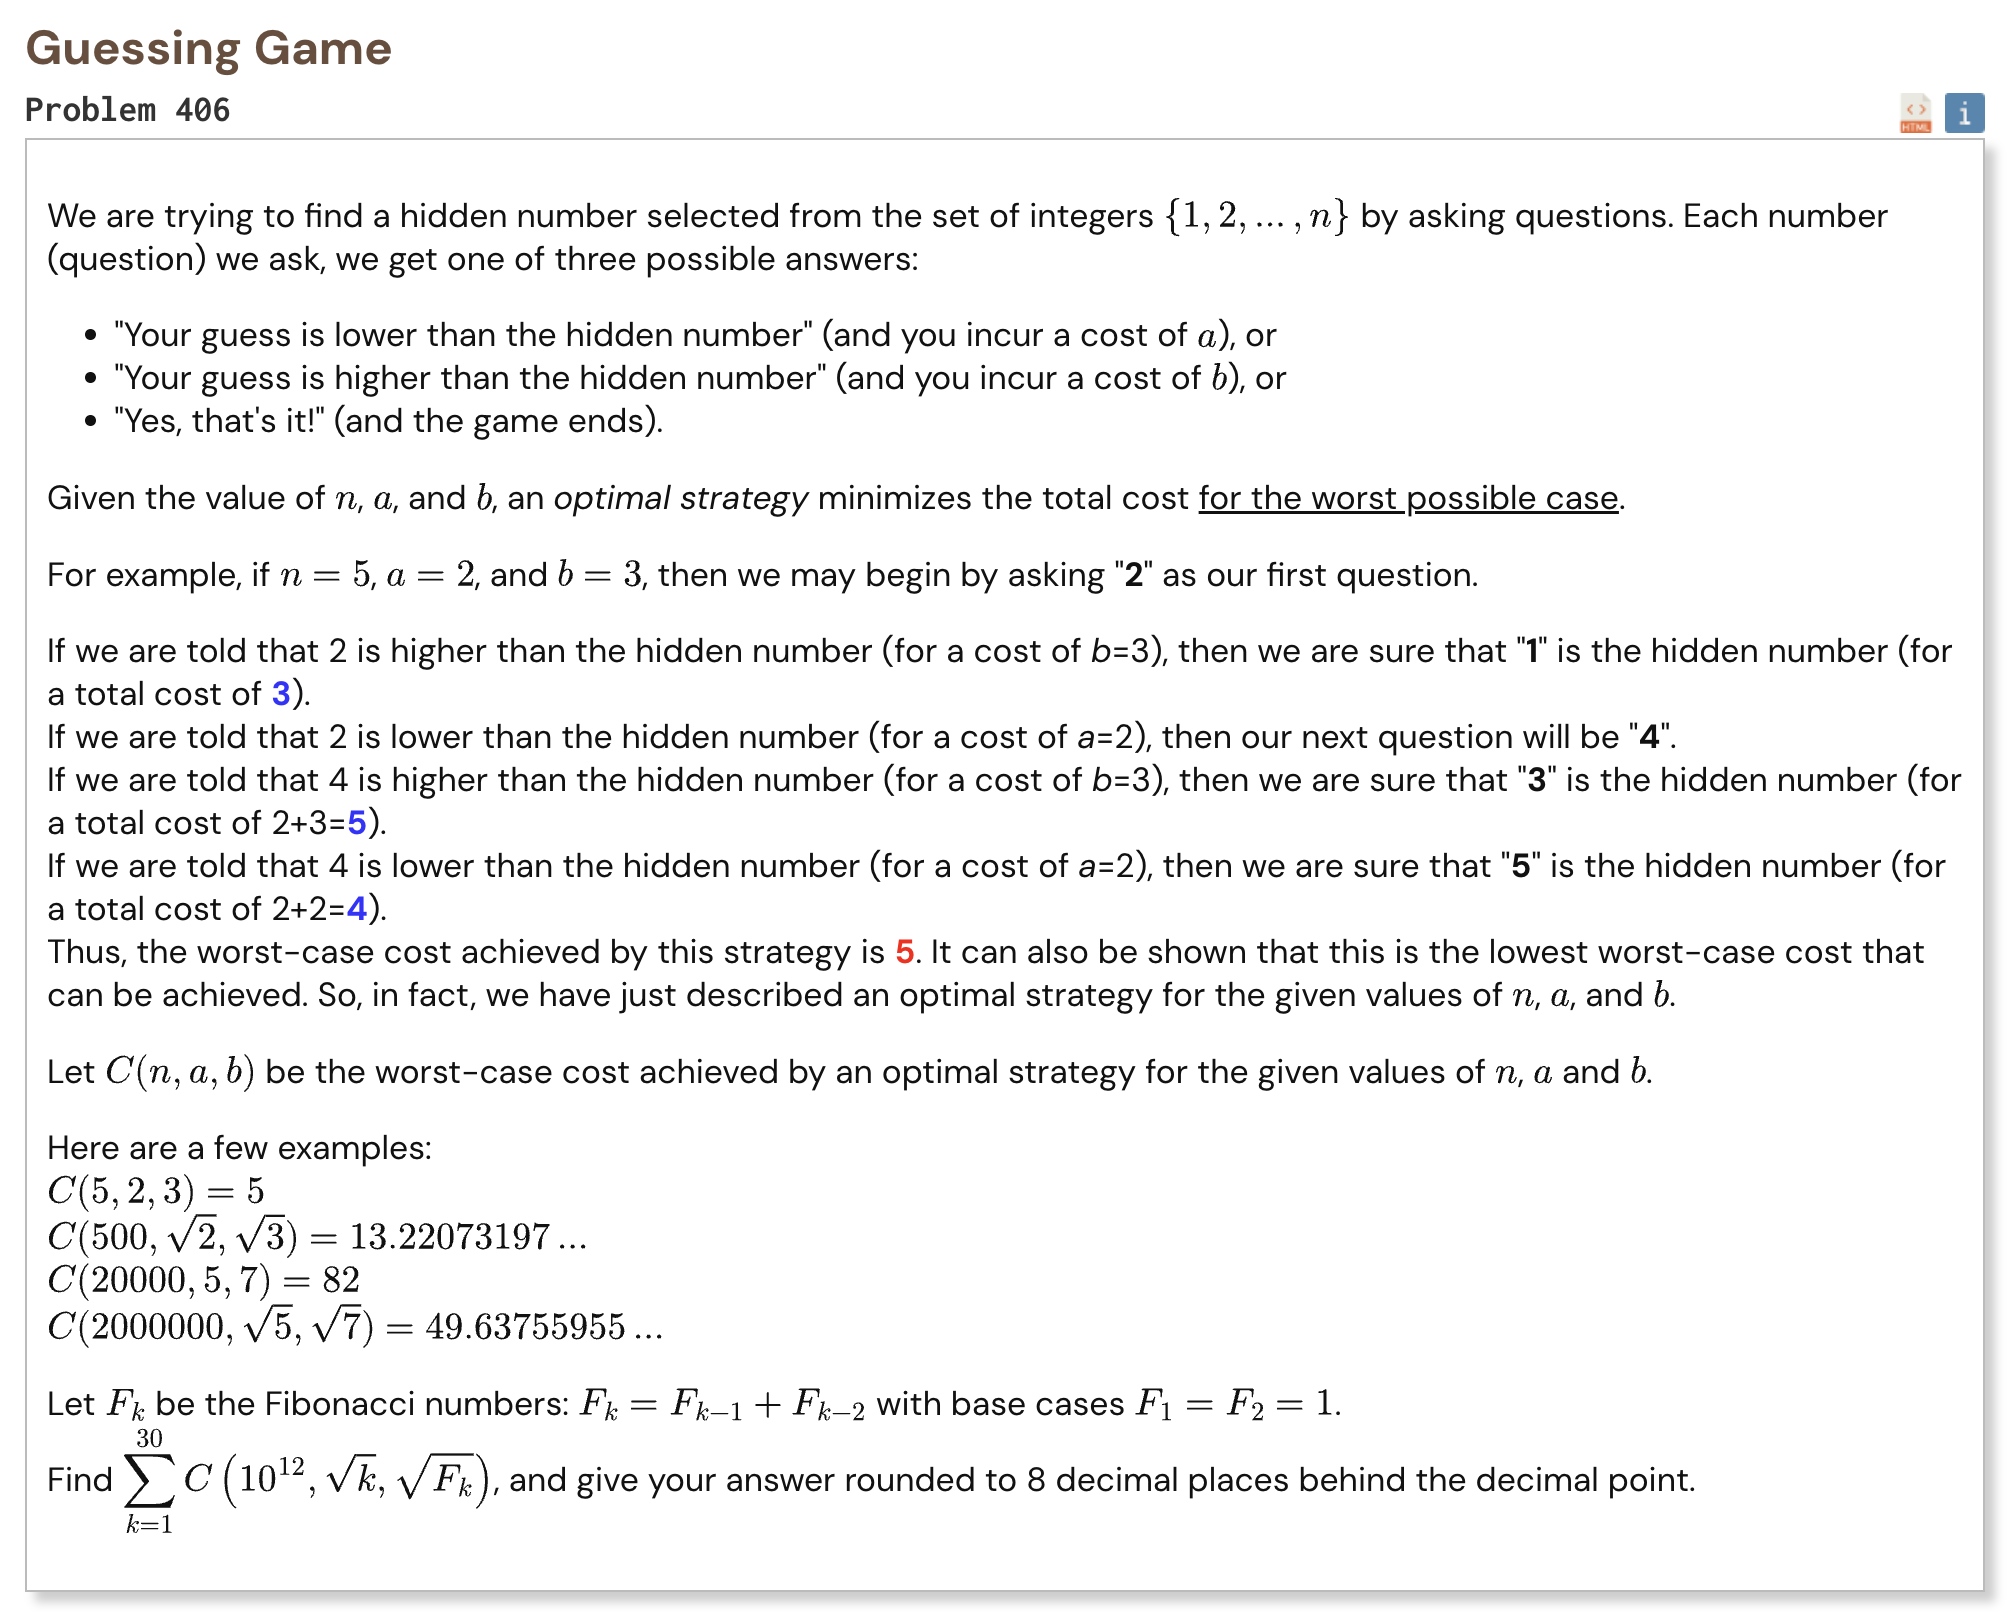

## Initial approach

* treat each possible remaining budget as a small game state
* store how many hidden numbers each state can handle
* combine the two possible wrong answer branches with the current guess
* stop growing a count once it reaches the required number
* use binary search to find the smallest sufficient total cost
* repeat this process for the first thirty Fibonacci numbers
* add the thirty optimal costs and round the result

In [1]:
%%time

from math import sqrt

def capacity(cost, low_cost, high_cost, target):
    max_low = int(cost / low_cost)
    max_high = int(cost / high_cost)
    next_row = [0] * (max_high + 2)

    for low_count in range(max_low, -1, -1):
        row = [0] * (max_high + 2)
        spent_low = low_count * low_cost

        for high_count in range(max_high, -1, -1):
            spent = spent_low + high_count * high_cost

            if spent <= cost + 1e-12:
                possible = 1 + next_row[high_count] + row[high_count + 1]
                row[high_count] = min(possible, target)

        next_row = row

    return next_row[0]

def optimal_cost(size, low_cost, high_cost):
    low = 0.0
    high = 1.0

    while capacity(high, low_cost, high_cost, size) < size:
        high *= 2

    for _ in range(100):
        middle = (low + high) / 2

        if capacity(middle, low_cost, high_cost, size) >= size:
            high = middle
        else:
            low = middle

    return high

fibonacci = [0, 1, 1]

for k in range(3, 31):
    fibonacci.append(fibonacci[-1] + fibonacci[-2])

total = 0.0

for k in range(1, 31):
    total += optimal_cost(
        10**12,
        sqrt(k),
        sqrt(fibonacci[k])
    )

result = f"{total:.8f}"
print("Result:", result)

Result: 36813.12757207
CPU times: user 1.55 s, sys: 7.95 ms, total: 1.56 s
Wall time: 1.56 s
